# SVM 与核方法 (Support Vector Machine & Kernel Methods)

本notebook通过代码和可视化来直观理解支持向量机(SVM)的核心思想，以及核方法(Kernel Methods)如何让SVM处理非线性可分的数据。

内容大纲：
1. 线性可分情况：最大间隔超平面与支持向量
2. 软间隔SVM：参数C的作用
3. 非线性数据与核技巧的动机
4. 核函数的几何直觉：低维映射到高维
5. 常见核函数对比：线性、多项式、RBF
6. RBF核中gamma参数的影响
7. 总结：SVM与核方法的关系

> 更详细的数学推导（拉格朗日对偶、KKT条件、Mercer定理等）可参考 CS229 笔记 `CS229_Chapter_5_Kernel_Methods.md`。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_blobs, make_circles, make_moons
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (启用3D绘图)

plt.rcParams['font.sans-serif'] = ['SimHei']  # 支持中文显示
plt.rcParams['axes.unicode_minus'] = False


def plot_svc_decision_function(model, ax=None, plot_support=True):
    """画出SVM的决策边界、+-1间隔线，以及支持向量"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    x = np.linspace(xlim[0], xlim[1], 60)
    y = np.linspace(ylim[0], ylim[1], 60)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # 决策边界 (P=0) 和间隔边界 (P=+-1)
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.6,
               linestyles=['--', '-', '--'])

    if plot_support and hasattr(model, "support_vectors_"):
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=180, linewidth=1.2,
                   facecolors='none', edgecolors='k', label='支持向量')

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

## 1. 线性可分情况：最大间隔超平面

SVM的核心思想：在所有能够正确分类数据的超平面中，找到**离两类数据点都最远**的那个超平面。

- 决策边界（超平面）：$w^T x + b = 0$
- 间隔 (margin)：图中两条虚线之间的距离，宽度为 $\dfrac{2}{\|w\|}$
- 支持向量 (support vectors)：恰好落在间隔边界上的样本点（图中被圈出的点），它们**唯一决定**了超平面的位置——其余点即使移动，只要不越过间隔边界，超平面都不会变。

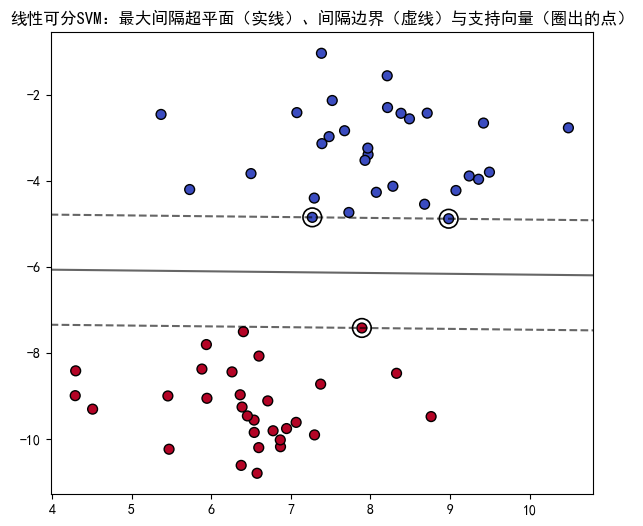

支持向量数量: 3
权重 w = [[-0.01499417 -0.78033295]]
偏置 b = [-4.6691987]


In [2]:
X, y = make_blobs(n_samples=60, centers=2, random_state=6, cluster_std=1.0)

# C取很大的值，相当于近似硬间隔（几乎不允许误分类）
model = SVC(kernel='linear', C=1e10).fit(X, y)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='coolwarm', edgecolors='k')
plot_svc_decision_function(model, ax)
ax.set_title("线性可分SVM：最大间隔超平面（实线）、间隔边界（虚线）与支持向量（圈出的点）")
plt.show()

print("支持向量数量:", len(model.support_vectors_))
print("权重 w =", model.coef_)
print("偏置 b =", model.intercept_)

## 2. 软间隔SVM：参数 C 的作用

现实数据往往有噪声或重叠，硬间隔SVM可能无解或严重过拟合。软间隔SVM引入松弛变量 $\xi_i \geq 0$，目标函数变为：

$$\min_{w,b,\xi} \ \frac{1}{2}\|w\|^2 + C\sum_{i=1}^n \xi_i \qquad \text{s.t.}\ \ y_i(w^Tx_i+b) \geq 1-\xi_i$$

- **C 越大**：对误分类的惩罚越重，间隔越窄，越容易过拟合（更贴近训练数据）
- **C 越小**：允许更多点进入间隔甚至被误分类，间隔越宽，模型更简单、泛化能力可能更好

下图展示了同一份（带重叠的）数据，在不同 C 值下决策边界和间隔的变化。

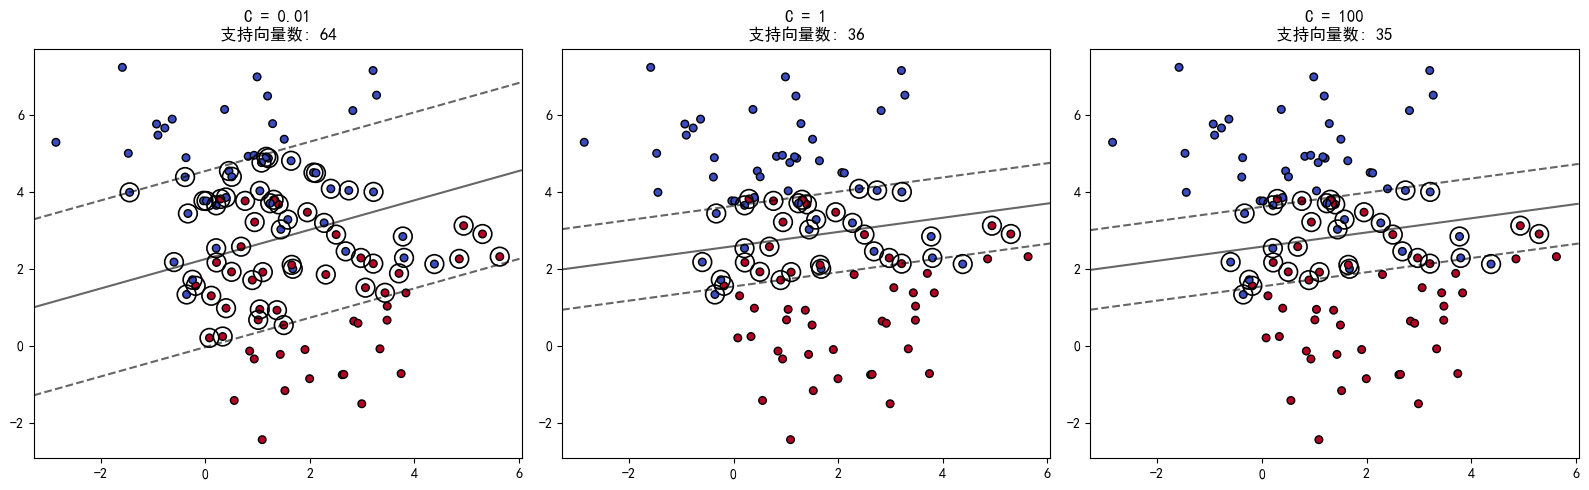

In [3]:
X, y = make_blobs(n_samples=100, centers=2, random_state=0, cluster_std=1.5)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, C in zip(axes, [0.01, 1, 100]):
    model = SVC(kernel='linear', C=C).fit(X, y)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap='coolwarm', edgecolors='k')
    plot_svc_decision_function(model, ax)
    ax.set_title(f"C = {C}\n支持向量数: {len(model.support_vectors_)}")

plt.tight_layout()
plt.show()

## 3. 非线性数据：线性SVM的局限

当数据本身不是线性可分的（例如下面这种环形分布），任何一条直线（或超平面）都无法很好地把两类分开。

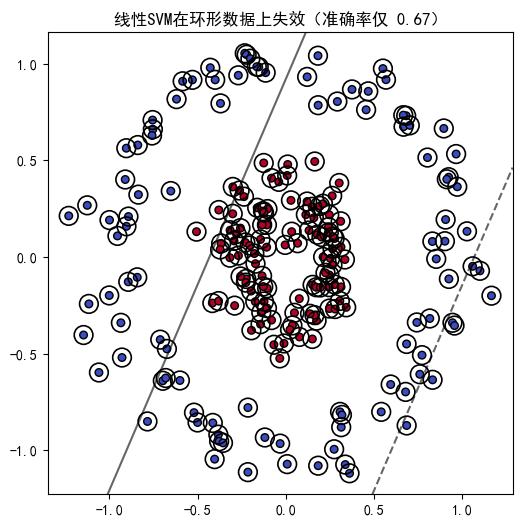

In [4]:
X, y = make_circles(n_samples=200, factor=0.3, noise=0.1, random_state=0)

model = SVC(kernel='linear', C=1).fit(X, y)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=30, edgecolors='k')
plot_svc_decision_function(model, ax)
ax.set_title(f"线性SVM在环形数据上失效（准确率仅 {model.score(X, y):.2f}）")
plt.show()

## 4. 核技巧的几何直觉：升维使其线性可分

核心想法：通过一个非线性映射 $\phi(x)$ 把数据映射到更高维空间，使其在高维空间中**变得线性可分**。

例如，对于上面的环形数据 $(x_1, x_2)$，可以构造一个简单的映射：

$$\phi(x_1, x_2) = (x_1,\ x_2,\ x_1^2 + x_2^2)$$

在这个新的3维空间中，内圈和外圈的点会在第三维（"高度"，即到原点的距离平方）上分开，从而可以用一个**水平面**把它们分开——而这个平面对应回原来的2维空间，就是一个**圆**。

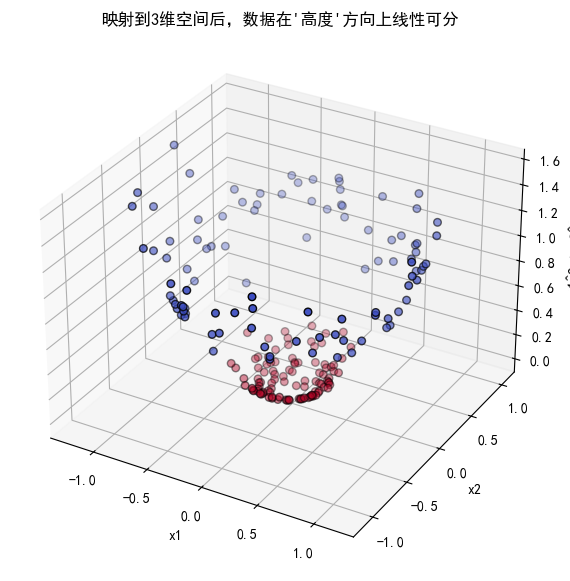

In [5]:
r = X[:, 0] ** 2 + X[:, 1] ** 2

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], r, c=y, cmap='coolwarm', s=30, edgecolors='k')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('x1^2 + x2^2')
ax.set_title("映射到3维空间后，数据在'高度'方向上线性可分")
plt.show()

## 5. 核函数：避免显式计算高维映射

直接构造并计算 $\phi(x)$（高维甚至无穷维向量）的代价可能极高。**核技巧 (Kernel Trick)** 的精髓在于：

$$K(x, z) = \phi(x)^T \phi(z)$$

我们只需要定义一个核函数 $K(x,z)$，直接计算两个样本在高维特征空间中的**内积**，而**不需要显式构造** $\phi$，甚至 $\phi$ 可以是无穷维的。

常见核函数：

| 核函数 | 公式 | 特点 |
|---|---|---|
| 线性核 (linear) | $K(x,z) = x^Tz$ | 等价于不做映射，适合本身线性可分的数据 |
| 多项式核 (poly) | $K(x,z) = (\gamma x^Tz + r)^d$ | 隐式包含原始特征的所有 $\leq d$ 次组合 |
| RBF / 高斯核 (rbf) | $K(x,z) = \exp(-\gamma\|x-z\|^2)$ | 对应无穷维特征空间，最常用、最通用 |

下图在环形数据上对比了这几种核函数的效果。

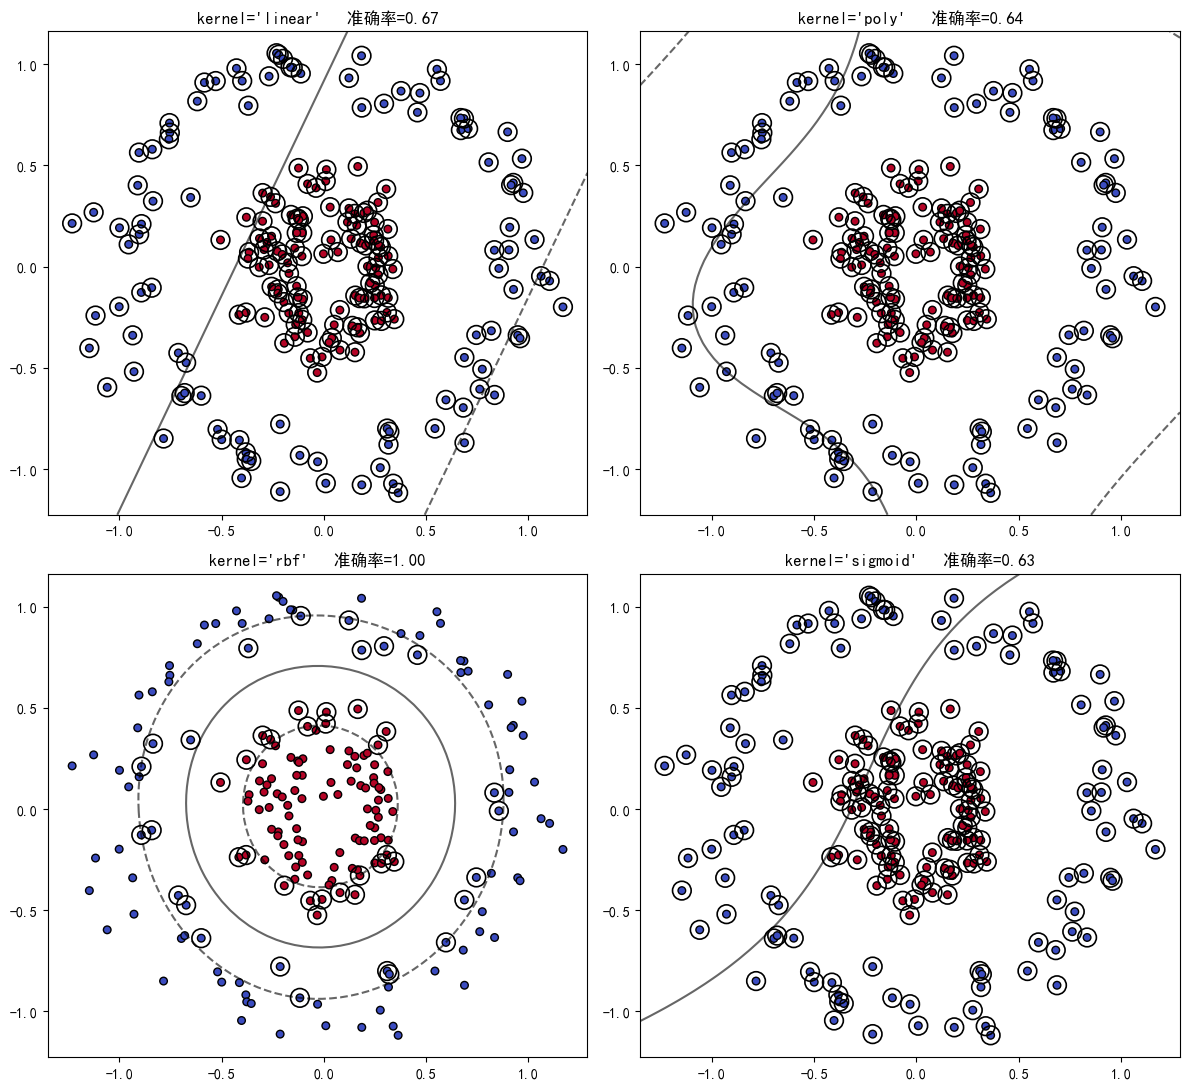

In [6]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
fig, axes = plt.subplots(2, 2, figsize=(12, 11))

for ax, kernel in zip(axes.ravel(), kernels):
    model = SVC(kernel=kernel, gamma='auto', C=1).fit(X, y)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=30, edgecolors='k')
    plot_svc_decision_function(model, ax)
    ax.set_title(f"kernel='{kernel}'   准确率={model.score(X, y):.2f}")

plt.tight_layout()
plt.show()

## 6. RBF核中 gamma 参数的影响

RBF核 $K(x,z) = \exp(-\gamma\|x-z\|^2)$ 中的 $\gamma$ 控制了每个样本"影响范围"的大小：

- **gamma 越大**：核函数衰减越快，每个样本只影响附近很小的区域 -> 决策边界越"曲折"，容易过拟合
- **gamma 越小**：每个样本的影响范围越大 -> 决策边界越平滑，可能欠拟合

可以把 $\gamma$ 类比成高斯分布的 $\dfrac{1}{2\sigma^2}$：$\gamma$ 越大，"钟形曲线"越窄。

下图在月牙形数据上展示了不同 gamma 值的效果（C 固定不变）。

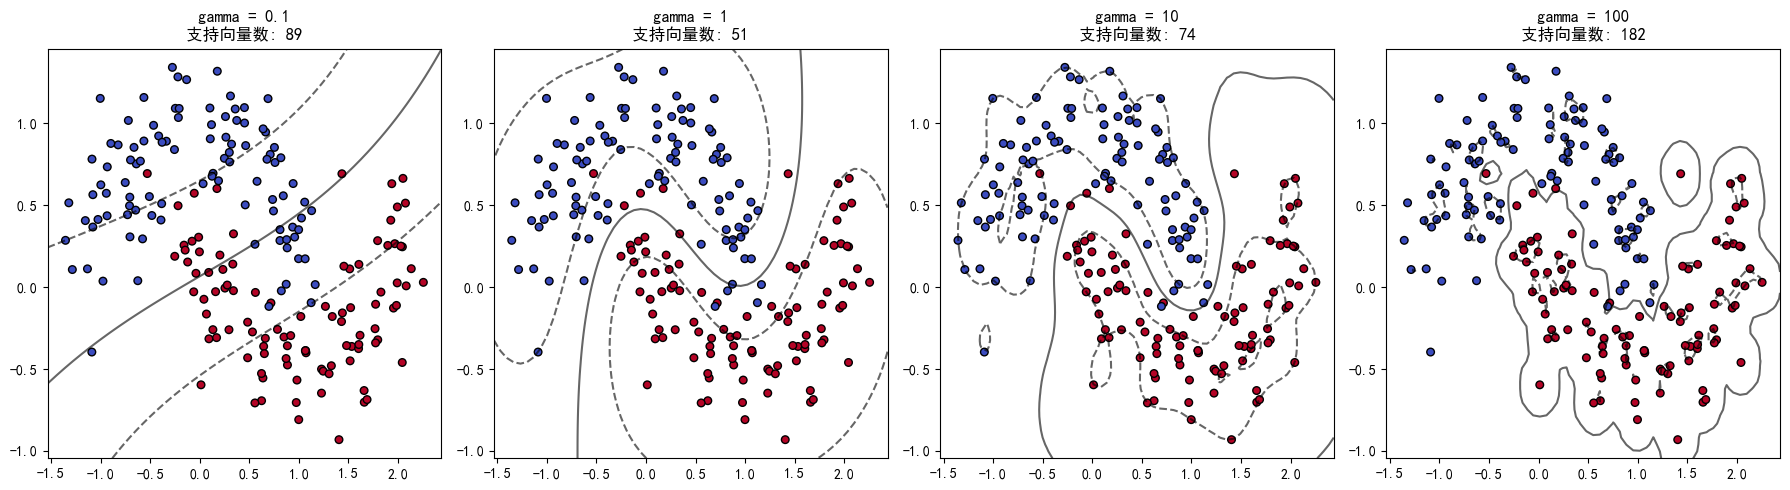

In [7]:
X2, y2 = make_moons(n_samples=200, noise=0.2, random_state=0)

gammas = [0.1, 1, 10, 100]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, gamma in zip(axes, gammas):
    model = SVC(kernel='rbf', gamma=gamma, C=1).fit(X2, y2)
    ax.scatter(X2[:, 0], X2[:, 1], c=y2, cmap='coolwarm', s=30, edgecolors='k')
    plot_svc_decision_function(model, ax, plot_support=False)
    ax.set_title(f"gamma = {gamma}\n支持向量数: {len(model.support_vectors_)}")

plt.tight_layout()
plt.show()

## 7. 总结：SVM 与核方法的关系

- **SVM** 本质上是一个寻找最大间隔超平面的**线性**分类器
- 求解SVM的**对偶问题**后，最终的决策函数只依赖于训练样本之间的**内积**：

$$f(x) = \text{sign}\left(\sum_{i} \alpha_i y_i \langle x_i, x\rangle + b\right)$$

- 由于决策函数只涉及内积 $\langle x_i, x\rangle$，我们可以用**核函数** $K(x_i,x)$ 替换它，从而**隐式地**在高维特征空间中做线性分类，而完全不需要显式计算映射 $\phi$
- 这就是**核技巧 (Kernel Trick)**：用线性算法解决非线性问题，"高维映射"和"内积计算"被合二为一、一步到位
- **C** 控制软间隔的容错程度，**gamma**（用于RBF/poly核）控制模型的复杂度/局部性——两者共同决定了模型的偏差-方差权衡（bias-variance tradeoff）

更详细的数学推导（拉格朗日对偶、KKT条件、Mercer定理、为什么核矩阵必须半正定等）可参考 `CS229_Chapter_5_Kernel_Methods.md` 笔记。